In [1]:
import os

import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

print("Package is ready.")

Package is ready.


In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [3]:
def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

In [4]:
SW2_df = pd.read_csv('./data/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [5]:
# SW2_df.index = SW2_df.index.round(freq='1 h')
# SW2_df = SW2_df.groupby(SW2_df.index).mean()

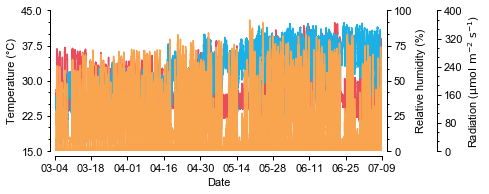

In [6]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.plot(SW2_df.index, SW2_df['temp'], c=cmap[0], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['hum'], c=cmap[4], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['rad'], c=cmap[2], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(15, 45)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(0, 400)

ax0.set_xlabel('Date')
ax0.set_ylabel('Temperature (°C)')
ax1.set_ylabel('Relative humidity (%)')
ax2.set_ylabel('Radiation (${\mu}mol{\ }m^{-2}{\ }s^{-1}$)')

fig.tight_layout()
fig.savefig('./figures/Fig1-1.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

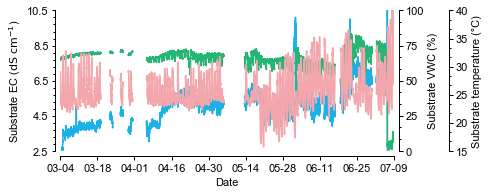

In [7]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.plot(SW2_df.index, SW2_df['subs_EC'], c=cmap[4], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['subs_VWC'], c=cmap[3], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['subs_temp'], c=cmap_m[0], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(21))
ax0.set_ybound(2.5, 10.5)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(15, 40)

ax0.set_xlabel('Date')
ax0.set_ylabel('Substrate EC ($dS{\ }cm^{-1}$)')
ax1.set_ylabel('Substrate VWC (%)')
ax2.set_ylabel('Substrate temperature (°C)')

fig.tight_layout()
fig.savefig('./figures/Fig1-2.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

## Loadcell weight

In [8]:
SW2_df = SW2_df[SW2_df['loadcell_1'] > 11].reindex(SW2_df.index)
SW2_df = SW2_df[SW2_df['loadcell_1'] < 25].reindex(SW2_df.index)
SW2_df = SW2_df[SW2_df['loadcell_2'] > 11].reindex(SW2_df.index)
SW2_df = SW2_df[SW2_df['loadcell_2'] < 25].reindex(SW2_df.index)
SW2_df = SW2_df[SW2_df['loadcell_3'] > 11].reindex(SW2_df.index)
SW2_df = SW2_df[SW2_df['loadcell_3'] < 25].reindex(SW2_df.index)

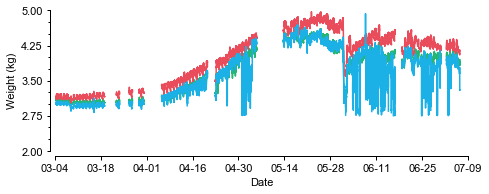

In [9]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(2, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
fig.savefig('./figures/Fig2.png', transparent=True, dpi=600, format='png')
plt.show() 

## Leaf area

In [10]:
leaf_area_df = pd.read_csv('./results/leaf_area.csv', index_col='Unnamed: 0')
leaf_area_df.columns = leaf_area_df.columns.astype('int')

In [11]:
leaf_area_df = leaf_area_df.rename(index={'2020-07-08':'2020-07-07'})
leaf_area_df = leaf_area_df.rename(index={'2020-07-09':'2020-07-07'})

In [12]:
__ = leaf_area_df.loc['2020-07-07'].values.reshape(1,-1)
__ = __[~np.isnan(__)].reshape(1,-1)
__= pd.DataFrame(__, index=['2020-07-07'])

In [13]:
leaf_area_df = leaf_area_df.drop(['2020-07-07'])

In [14]:
leaf_area_df = leaf_area_df.append(__)

In [15]:
leaf_area_df.index = pd.DatetimeIndex(leaf_area_df.index)

In [16]:
leaf_area_df.mean(axis=1)

2020-03-24     2134.356667
2020-04-21     7320.930000
2020-05-22    12664.820000
2020-06-17    15156.470000
2020-07-07    12291.404000
dtype: float64

In [17]:
leaf_area_df.index - pd.datetime(2020, 2, 26)

TimedeltaIndex(['27 days', '55 days', '86 days', '112 days', '132 days'], dtype='timedelta64[ns]', freq=None)

In [18]:
la_er_df = leaf_area_df.sem(axis=1)

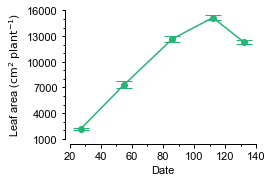

In [19]:
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.errorbar(x_labels, leaf_area_df.mean(axis=1), la_er_df,
            linestyle='-', linewidth=1.5, marker='o', capsize=8, elinewidth=1, color=cmap[3])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(16))
ax0.set_ybound(1000, 16000)

ax0.set_xlabel('Date')
ax0.set_ylabel('Leaf area ($cm^{2}\ plant^{-1}$)')

fig.savefig('./figures/Fig3A.svg', transparent=True, format='svg')

## Destructive weight

In [20]:
weight_df = pd.read_csv('./results/weight.csv', index_col='Unnamed: 0')

In [21]:
weight_df.index = pd.DatetimeIndex(weight_df.index)

In [22]:
w_er_df = weight_df.groupby(weight_df.index).sem()
weight_df = weight_df.groupby(weight_df.index).mean()

In [23]:
weight_df.index - pd.datetime(2020, 2, 26)

TimedeltaIndex(['27 days', '55 days', '86 days', '112 days', '132 days'], dtype='timedelta64[ns]', freq=None)

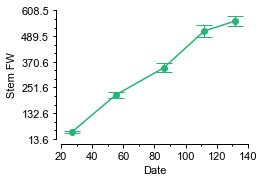

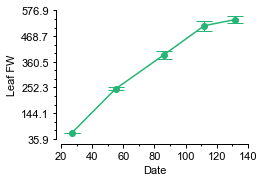

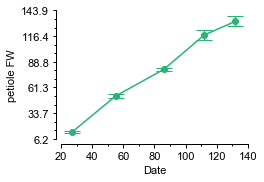

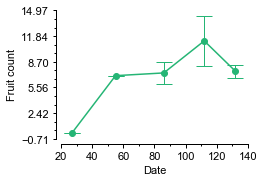

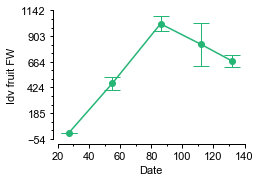

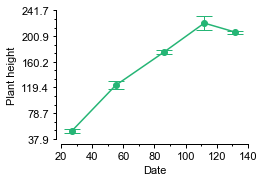

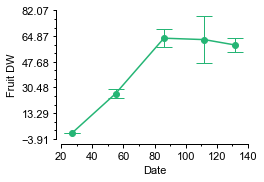

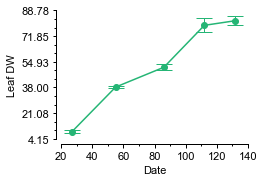

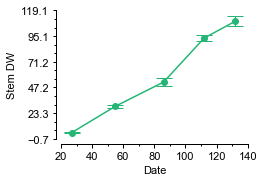

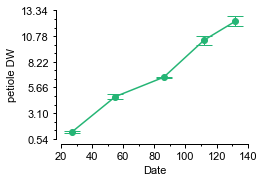

In [24]:
for i in range(10):
    fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
    ax0 = plt.subplot()

    x_labels = [27, 55, 86, 112, 132]
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.spines['bottom'].set_position(('outward', 5))


    ax0.errorbar(x_labels, weight_df.iloc[:, i], w_er_df.iloc[:, i],
                linestyle='-', linewidth=1.5, marker='o', capsize=8, elinewidth=1, color=cmap[3])

    ax0.set_xbound(20, 140)
    ax0.xaxis.set_major_locator(LinearLocator(7))
    ax0.xaxis.set_minor_locator(LinearLocator(13))

    ax0.yaxis.set_major_locator(LinearLocator(6))
    ax0.yaxis.set_minor_locator(LinearLocator(16))
    #ax0.set_ybound(1000, 16000)

    ax0.set_xlabel('Date')
    ax0.set_ylabel(weight_df.columns[i])

    fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')

In [25]:
weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']]

,Stem FW,Leaf FW,petiole FW,Idv fruit FW
2020-03-24,45.333333,61.333333,13.333333,0.000000
2020-04-21,216.000000,246.000000,52.000000,462.000000
2020-05-22,342.666667,389.333333,80.666667,1017.333333
2020-06-17,513.000000,512.500000,117.500000,826.000000
2020-07-07,559.500000,538.400000,132.200000,670.250000


In [61]:
SW2_df.index = SW2_df.index.round(freq='1 d')
SW2_df = SW2_df.groupby(SW2_df.index).mean()

In [68]:
SW2_df.index = np.arange(8, 136)

Text(0, 0.5, 'Fresh weight (kg)')

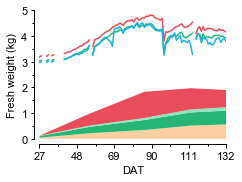

In [86]:
stack_cmap = [cmap_m[2], cmap[3], cmap_m[3], cmap[0]]
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.stackplot(x_labels, weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].T/1000, colors=stack_cmap)
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(27, 132)
ax0.xaxis.set_major_locator(LinearLocator(6))
ax0.xaxis.set_minor_locator(LinearLocator(11))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')

Text(0, 0.5, 'Fresh weight (kg)')

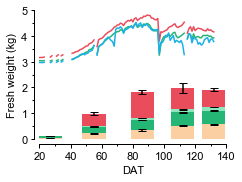

In [89]:
wid = 15
ys = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
yer = w_er_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.bar(x_labels, ys[:, 0], yerr=yer[:, 0], width=wid, capsize=4, color=cmap_m[2])
ax0.bar(x_labels, ys[:, 1], yerr=yer[:, 1], width=wid, capsize=4, bottom=ys[:, 0], color=cmap[3])
ax0.bar(x_labels, ys[:, 2], yerr=yer[:, 2], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1], color=cmap_m[3])
ax0.bar(x_labels, ys[:, 3], yerr=yer[:, 3], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2], color=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')


## SPAD

In [29]:
spad_df = pd.read_excel('./data/nondestructive/SPAD.xlsx', index_col='Unnamed: 0')

In [30]:
spad_df.index - pd.datetime(2020, 2, 26)

TimedeltaIndex([ '27 days',  '48 days',  '49 days',  '51 days',  '54 days',
                 '56 days',  '58 days',  '61 days',  '63 days',  '65 days',
                 '68 days',  '71 days',  '72 days',  '75 days',  '77 days',
                 '84 days',  '86 days',  '90 days',  '91 days',  '93 days',
                 '96 days',  '98 days', '100 days', '103 days', '107 days',
                '112 days', '114 days', '119 days', '121 days', '124 days',
                '126 days'],
               dtype='timedelta64[ns]', freq=None)

In [31]:
spad_df.columns = ['SPAD_l', 'SPAD_l', 'SPAD_l', 'SPAD_m', 'SPAD_m', 'SPAD_m', 'SPAD_u', 'SPAD_u', 'SPAD_u']

In [32]:
spad_er_df = spad_df.groupby(spad_df.columns, axis=1).sem()
spad_df = spad_df.groupby(spad_df.columns, axis=1).mean()

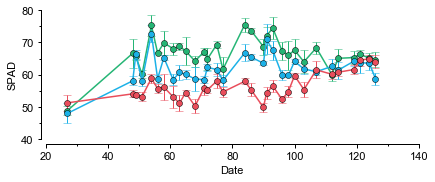

In [92]:
fig = plt.figure(figsize=((8.5/2.54)*2, (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 48, 49, 51, 54, 56, 58, 61, 63, 65, 68, 71, 72, 75, 77, 84, 86, 90, 91, 93, 96, 98, 100, 103, 107, 112, 114, 119, 121, 124, 126]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.errorbar(x_labels, spad_df['SPAD_l'], spad_er_df['SPAD_l'],
            linestyle='-', linewidth=1.5, marker='o', mec='k', mew=0.5, capsize=4, elinewidth=1, color=cmap[3])
ax0.errorbar(x_labels, spad_df['SPAD_m'], spad_er_df['SPAD_m'],
            linestyle='-', linewidth=1.5, marker='o', mec='k', mew=0.5, capsize=4, elinewidth=1, color=cmap[4])
ax0.errorbar(x_labels, spad_df['SPAD_u'], spad_er_df['SPAD_u'],
            linestyle='-', linewidth=1.5, marker='o', mec='k', mew=0.5, capsize=4, elinewidth=1, color=cmap[0])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(9))
ax0.set_ybound(40, 80)

ax0.set_xlabel('Date')
ax0.set_ylabel('SPAD')

fig.savefig('./figures/Fig3C.svg', transparent=True, format='svg')

## DISUSE

SW2_df.index = SW2_df.index.round(freq='1 d')
SW2_df = SW2_df.groupby(SW2_df.index).mean()

SW2_df.index = np.arange(8, 136)

stack_cmap = [cmap[2], cmap_m[2], cmap[3], cmap_m[3], cmap[0]]
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.stackplot(x_labels, weight_df[['Root FW', 'Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].T/1000, colors=stack_cmap)
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(27, 132)
ax0.xaxis.set_major_locator(LinearLocator(6))
ax0.xaxis.set_minor_locator(LinearLocator(11))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')

wid = 15
ys = weight_df[['Root FW', 'Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
yer = w_er_df[['Root FW', 'Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].values/1000
fig = plt.figure(figsize=((8.5/2.54), (6/2.54)))
ax0 = plt.subplot()

x_labels = [27, 55, 86, 112, 132]
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))


ax0.bar(x_labels, ys[:, 0], yerr=yer[:, 0], width=wid, capsize=4, color=cmap[2])
ax0.bar(x_labels, ys[:, 1], yerr=yer[:, 1], width=wid, capsize=4, bottom=ys[:, 0], color=cmap_m[2])
ax0.bar(x_labels, ys[:, 2], yerr=yer[:, 2], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1], color=cmap[3])
ax0.bar(x_labels, ys[:, 3], yerr=yer[:, 3], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2], color=cmap_m[3])
ax0.bar(x_labels, ys[:, 4], yerr=yer[:, 4], width=wid, capsize=4, bottom=ys[:, 0]+ys[:, 1]+ys[:, 2]+ys[:, 3], color=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap[3])
ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap[4])

ax0.set_xbound(20, 140)
ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(0, 5)

ax0.set_xlabel('DAT')
ax0.set_ylabel('Fresh weight (kg)')

#fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')
